### Importing modules and loading the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score , f1_score

df = pd.read_csv('telco_customer_churn.csv')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'] , errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median() , inplace = True)

df['Churn'] = df['Churn'].map({'Yes':1 , 'No':0})

print("Shape: ", df.shape )


Shape:  (7043, 21)


C:\Users\sawmi\AppData\Local\Temp\ipykernel_5348\1771077164.py:18: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TotalCharges'].fillna(df['TotalCharges'].median() , inplace = True)


# Exploratory Data Analysis

### 2. Dataset Description


C:\Users\sawmi\AppData\Local\Temp\ipykernel_5776\2876835207.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


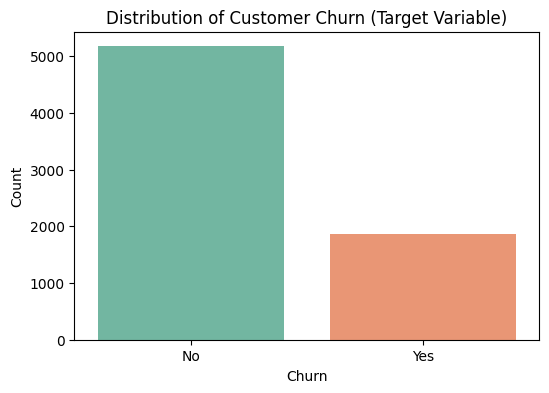

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Distribution of Customer Churn (Target Variable)')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

print(df['Churn'].value_counts())

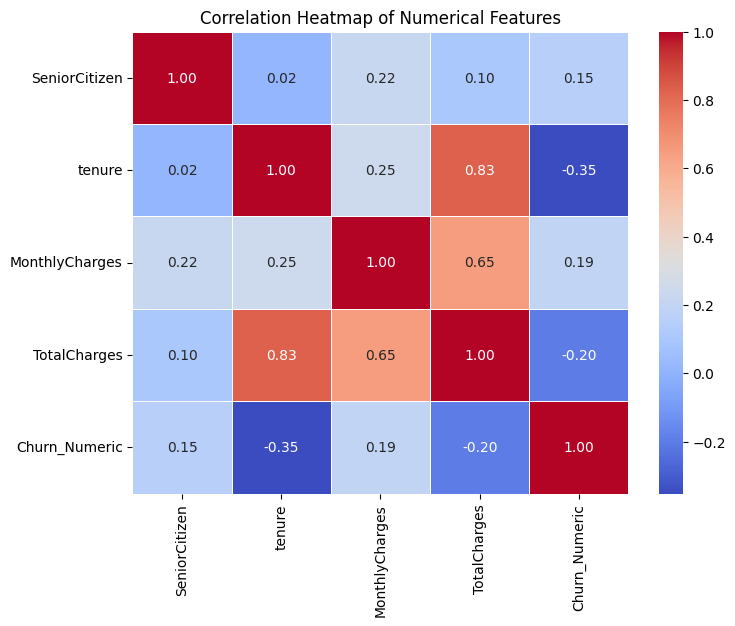

C:\Users\sawmi\AppData\Local\Temp\ipykernel_5776\2924404914.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='pastel')


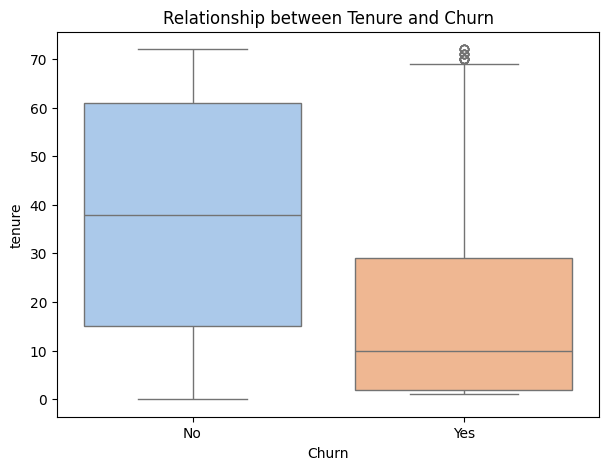

In [18]:
# Temporary copy for EDA
df_eda = df.copy()

# 1. Convert TotalCharges to numeric
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce')

# Converting Churn to 1s and 0s just for the heatmap
df_eda['Churn_Numeric'] = df_eda['Churn'].map({'Yes': 1, 'No': 0})

numeric_cols = df_eda[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Numeric']]

# Plotting the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Extracting an important relationship (EDA)
plt.figure(figsize=(7, 5))
sns.boxplot(x='Churn', y='tenure', data=df, palette='pastel')
plt.title('Relationship between Tenure and Churn')
plt.show()

### 3. Dataset Pre-processing

#### Null / Missing Values and Useless Features


In [19]:

#dropping customerID since it is not useful for modeling

df = df.drop(columns=['customerID'])

# Fixing the total charge columnn by replacing the empty spaces with NaN and then converting it to numeric 
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Imputing/filling the missing values in TotalCharges with the median value
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print("Missing values after imputation:", df['TotalCharges'].isnull().sum())



Missing values after imputation: 0


#### Categorical Values

In [20]:
from sklearn.preprocessing import LabelEncoder

#Encoding the categorical variables
cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in cols:
    df[col] = le.fit_transform(df[col])

#Encoding multi-option categorical variables
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
              'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols , drop_first=True , dtype=int)
print(f"Data shape after encoding: {df.shape}")

Data shape after encoding: (7043, 31)


#### Feature Scaling

In [21]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

#Selecting the numeric columns to be scaled
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

df[num_cols] = scaler.fit_transform(df[num_cols])

display(df.head())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,0.013889,0,1,0.115423,0.001275,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0.472222,1,0,0.385075,0.215867,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,0.027778,1,1,0.354229,0.010310,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0.625000,0,0,0.239303,0.210241,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0.027778,1,1,0.521891,0.015330,1,...,0,0,0,0,0,0,0,0,1,0


### 4. Dataset Splitting

In [22]:
from sklearn.model_selection import train_test_split

#seperating the input and outputs
X = df.drop('Churn', axis=1)
Y = df['Churn']

#Performing a 80/20 stratified split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y) #random_state is a specific seed value for reproducibility

# Verify the shapes of our new datasets
print("--- Data Splitting Complete ---")
print(f"Total dataset shape: {df.shape}")
print(f"X_train shape (80% features): {X_train.shape}")
print(f"X_test shape (20% features): {X_test.shape}")
print(f"Y_train shape (80% target): {Y_train.shape}")
print(f"Y_test shape (20% target): {Y_test.shape}")

--- Data Splitting Complete ---
Total dataset shape: (7043, 31)
X_train shape (80% features): (5634, 30)
X_test shape (20% features): (1409, 30)
Y_train shape (80% target): (5634,)
Y_test shape (20% target): (1409,)


### 5. Unsupervised Learning (K-Means Clustering)

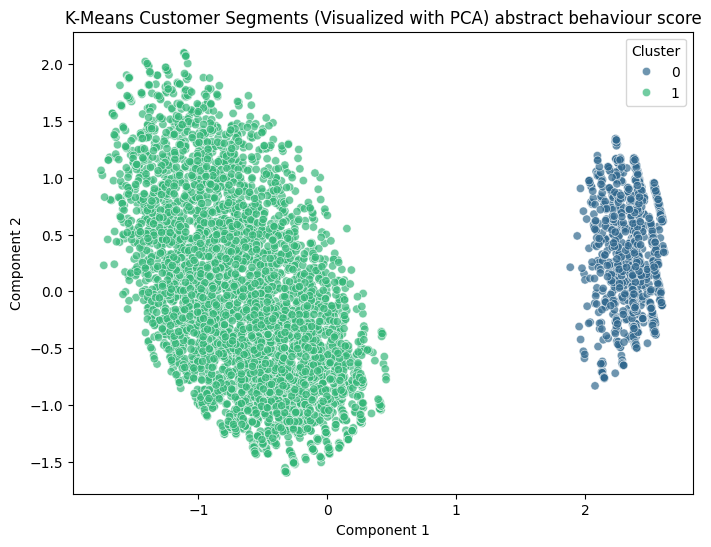

In [23]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

kmeans = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans.fit_predict(X_train)


#Using PCA to reduce the dimensionality of the data to 2D for visualization 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

#DataFrame for the plot 
pca_df = pd.DataFrame(data=X_pca, columns=['Component 1', 'Component 2'])
pca_df['Cluster'] = cluster_labels

#Plotting the clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Component 1', y='Component 2', hue='Cluster',data=pca_df, palette='viridis',alpha = 0.7) #alpha is used to make the points slightly transparent for better visibilitys
plt.title('K-Means Customer Segments (Visualized with PCA) abstract behaviour score')
plt.show()

### 5. Model Training & Testing (Supervised)
* To train multiple supervised classification models on our 80% training data and generate predictions on our 20% testing data.
* **Models Selected:**
    1. **Logistic Regression:** A strong, interpretable baseline model.
    2. **Decision Tree:** A non-linear, rule-based model.
    3. **Neural Network:** A complex deep learning model to capture hidden patterns.

#### Model 1: Logistic Regression

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model  = LogisticRegression(random_state=42)

log_model.fit(X_train, Y_train)

log_predictions = log_model.predict(X_test)

log_accuracy = accuracy_score(Y_test, log_predictions)
print(f"Logistic Regression Accuracy: {log_accuracy * 100:.2f}%")


Logistic Regression Accuracy: 79.84%


#### Model 2: Naive Bayes (GaussianNB)

In [25]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train, Y_train)

nb_pred = nb_model.predict(X_test)

nb_accuracy = accuracy_score(Y_test, nb_pred)
print(f"Naive Bayes Accuracy: {nb_accuracy * 100:.2f}%")

Naive Bayes Accuracy: 65.58%


#### Model 3: Neural Network (MLP Classifier)

In [26]:
from sklearn.neural_network import MLPClassifier

neural_model = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500 , random_state=42) #max_iter is the maximum number of iterations for the solver to converge

neural_model.fit(X_train, Y_train)

neural_model_pred = neural_model.predict(X_test)

neural_accuracy = accuracy_score(Y_test, neural_model_pred)
print(f"Neural Network Accuracy: {neural_accuracy * 100:.2f}%")

Neural Network Accuracy: 75.66%


### 6. Model Selection & Comparison Analysis

In [27]:
from sklearn.metrics import classification_report

# report for Logistic Regression
print("--- Logistic Regression ---")
print(classification_report(Y_test, log_predictions))


# report for the Neural Network
print("\n--- Neural Network ---")
print(classification_report(Y_test, neural_model_pred))

# report for Naive Bayes
print("\n--- Naive Bayes ---") 
print(classification_report(Y_test, nb_pred))


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409


--- Neural Network ---
              precision    recall  f1-score   support

           0       0.83      0.84      0.84      1035
           1       0.54      0.51      0.53       374

    accuracy                           0.76      1409
   macro avg       0.69      0.68      0.68      1409
weighted avg       0.75      0.76      0.75      1409


--- Naive Bayes ---
              precision    recall  f1-score   support

           0       0.92      0.58      0.71      1035
           1       0.43      0.87      0.57       374

    accuracy                           0.66      1409
   macro avg       0.67      0.72      0.64      1409
w

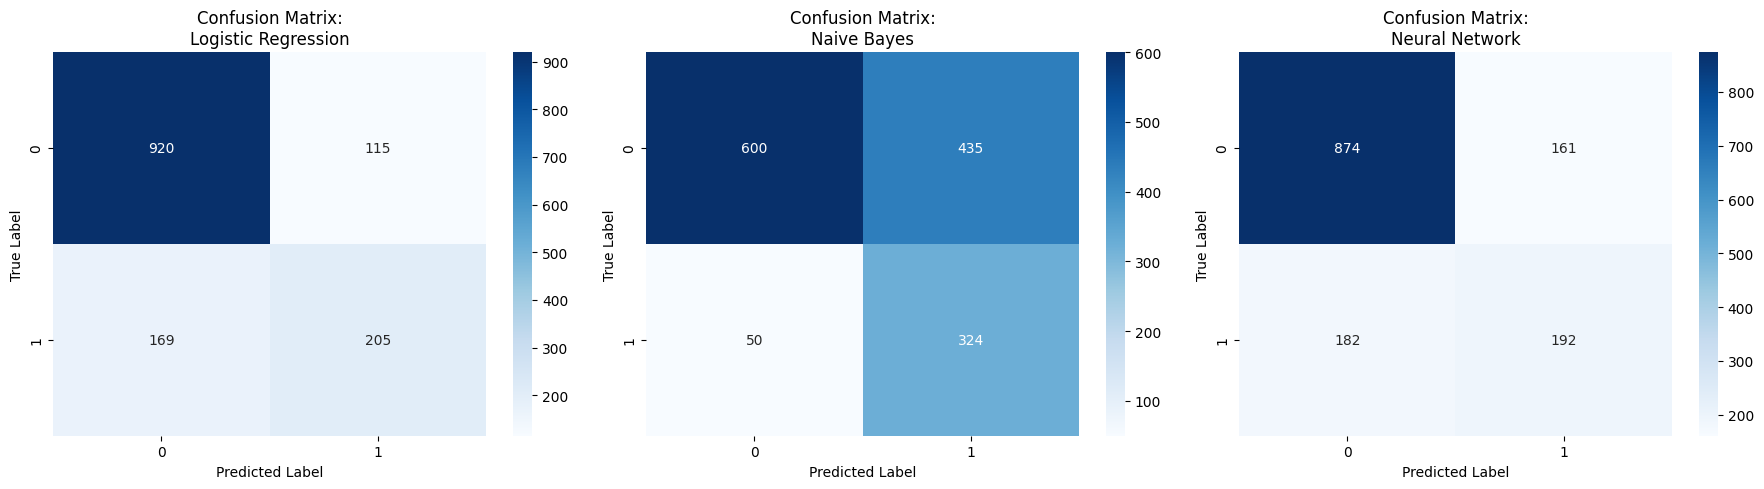

C:\Users\sawmi\AppData\Local\Temp\ipykernel_5776\730190706.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette='viridis')


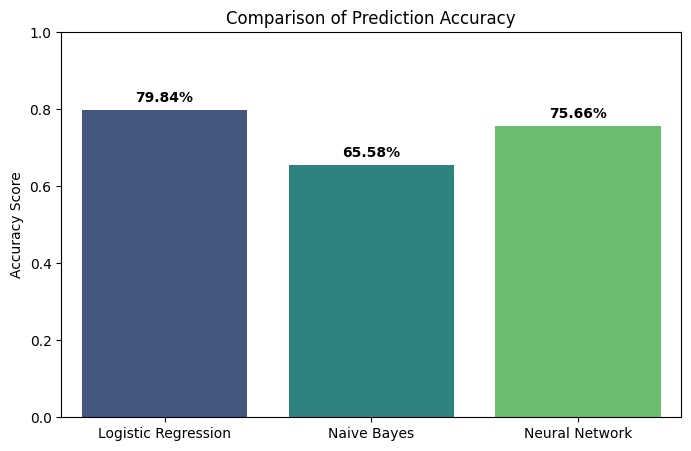

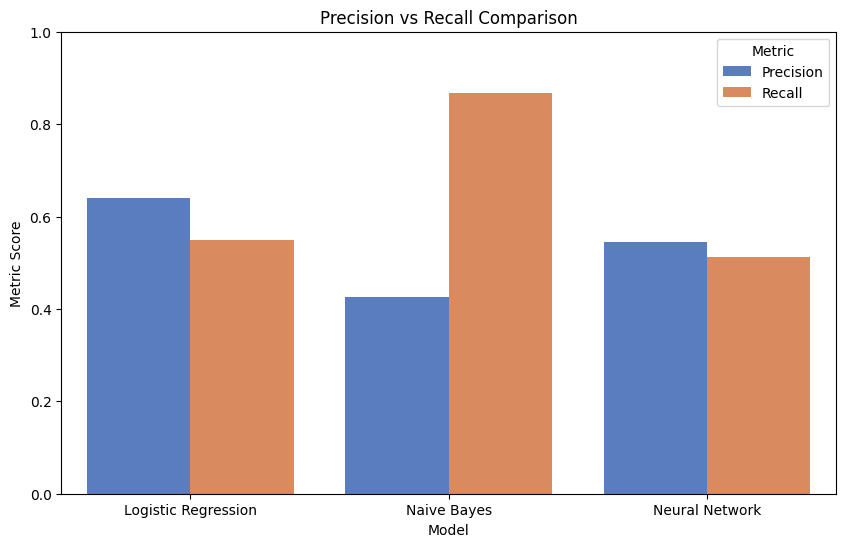

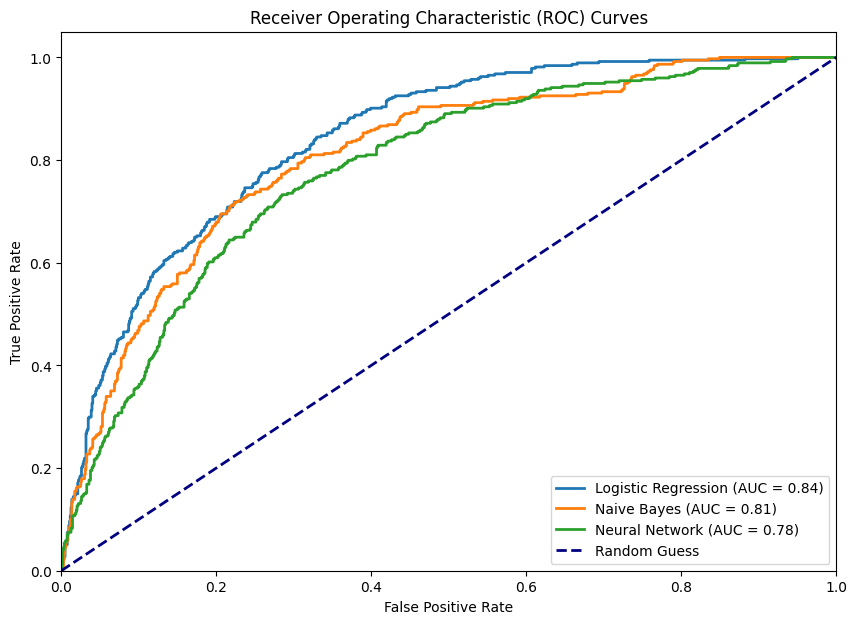

--- Regression Metrics (Applied to Classification Probabilities) ---
Neural Network -> R2 Score: 0.0457 | Log Loss: 0.7609


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve, auc, r2_score, log_loss)

# 1. SETUP DATA FOR COMPARISON
# models dictionary for easier iteration
models = {
    'Logistic Regression': log_model,
    'Naive Bayes': nb_model,
    'Neural Network': neural_model
}

model_names = []
accuracies = []
precisions = []
recalls = []
auc_scores = []


# 2. CALCULATION & CONFUSION MATRICES
# 1x3 subplot for the confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Calculate Classification Metrics
    acc = accuracy_score(Y_test, y_pred)
    prec = precision_score(Y_test, y_pred)
    rec = recall_score(Y_test, y_pred)
    
    # Calculate AUC Score
    fpr, tpr, _ = roc_curve(Y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    # Store results
    model_names.append(name)
    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    auc_scores.append(roc_auc)
    
    # Plot Confusion Matrix
    cm = confusion_matrix(Y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Confusion Matrix:\n{name}')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()


# 3. ACCURACY BAR CHART
# Showcasing which model is the most accurate overall
plt.figure(figsize=(8, 5))
sns.barplot(x=model_names, y=accuracies, palette='viridis')
plt.title('Comparison of Prediction Accuracy')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1.0) # Accuracy is between 0 and 1
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')
plt.show()

# 4. PRECISION & RECALL COMPARISON
# A DataFrame for a grouped bar chart
comparison_df = pd.DataFrame({
    'Model': model_names,
    'Precision': precisions,
    'Recall': recalls
})
melted_df = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=melted_df, x='Model', y='Score', hue='Metric', palette='muted')
plt.title('Precision vs Recall Comparison')
plt.ylabel('Metric Score')
plt.ylim(0, 1.0)
plt.show()

# 5. ROC CURVES & AUC SCORE
# Visualizing the relationship between True Positive and False Positive rates
plt.figure(figsize=(10, 7))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(Y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.show()

# 6. R2 SCORE & LOSS (Regression Specific)
print("--- Regression Metrics (Applied to Classification Probabilities) ---")

y_prob = model.predict_proba(X_test)[:, 1]

r2 = r2_score(Y_test, y_prob)
# Loss: Cross-Entropy / Log Loss
loss = log_loss(Y_test, y_prob)

print(f"{name} -> R2 Score: {r2:.4f} | Log Loss: {loss:.4f}")